In [2]:
import pandas as pd

data = pd.read_csv("../../Data/Second-System-Full-Data3.csv")
data

,Insert-Atom,Pt-Fold,Melting-point1,Melting-point2,Melting-point-Average,Density1,Density2,Density-Average,Ionization-energy1,Ionization-energy2,...,Work-function,p-center,d-center,mag,Bader-1,Bader-2,*O,*OH,*OOH,delta G
0,Sc-Ti,1,1541.0,1668.0,1604.5,2.99,4.51,3.750,6.5,6.8,...,5.358,0.217,-2.357,13.7758,-0.210490,-0.809957,-4.668238,-2.877284,-1.594718,1.146129
1,Sc-V,1,1541.0,1910.0,1725.5,2.99,6.11,4.550,6.5,6.7,...,5.359,1.410,-2.212,15.1795,-0.336005,-0.059053,-3.818548,-2.394374,-1.561248,0.782372
2,Sc-Cr,1,1541.0,1970.0,1755.5,2.99,7.14,5.065,6.5,7.4,...,5.358,0.272,-2.338,14.8084,-0.370200,0.077698,-3.809428,-2.665324,-1.554578,0.493154
3,Sc-Mn,1,1541.0,1246.0,1393.5,2.99,7.47,5.230,6.5,7.9,...,5.353,1.520,-2.106,18.7501,-0.385765,0.134615,-4.405968,-1.403044,-0.790438,2.335236
4,Sc-Fe,1,1541.0,1538.0,1539.5,2.99,7.87,5.430,6.5,7.8,...,5.357,0.565,-2.238,15.1865,-0.398879,0.261681,-4.718638,-2.284104,-1.878618,1.783211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,Rh-Os,2,1964.0,3033.0,2498.5,12.45,22.61,17.530,7.4,8.4,...,5.684,1.850,-1.901,2.9641,0.163280,-0.352788,-3.910258,-1.963814,-1.442868,1.299940
360,Rh-Ir,2,1964.0,2466.0,2215.0,12.45,22.65,17.550,7.4,8.9,...,5.710,1.790,-1.937,12.8147,-0.012304,-0.186962,-5.026828,-3.472184,-2.282198,0.901419
361,Pd-Os,2,1555.0,3033.0,2294.0,12.02,22.61,17.315,8.3,8.4,...,5.702,0.643,-2.043,2.6793,0.271510,-0.373611,-4.097058,-2.035934,-1.834308,1.410627
362,Pd-Ir,2,1555.0,2466.0,2010.5,12.02,22.65,17.335,8.3,8.9,...,5.724,0.606,-2.054,9.6790,0.234508,-0.189225,-4.392528,-2.475244,-1.281808,1.272229


In [3]:
X_D = data.drop(["delta G","Insert-Atom","Pt-Fold","Melting-point1","Density1","Ionization-energy1","Atomic-mass1","ID-1","Radius-1","Electronegativity-1","Formation-Energy","d-center"],axis=1).values
y_D = data["delta G"].values

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X_D, y_D, test_size=0.2, random_state=42)
#X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=2/3, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
#X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def plot_true_vs_predicted(y_train, y_train_pred, y_test, y_test_pred, r2_train, r2_test, model_name="Random Forest",
                           Prediction="GeltaG", output_file=None):
    """
    绘制真实值与预测值的对比图，包含训练集和测试集的散点图和回归线。

    参数：
    - y_train: array-like, 训练集真实值
    - y_train_pred: array-like, 训练集预测值
    - y_test: array-like, 测试集真实值
    - y_test_pred: array-like, 测试集预测值
    - r2_train: float, 训练集 R^2 值
    - r2_test: float, 测试集 R^2 值
    - model_name: str, 模型名称（默认 "Random Forest"）
    - output_file: str, 可选，保存输出图像的文件路径（默认 None，表示不保存）

    返回：
    - 显示生成的图像。
    """
    # 设置字体为 Times New Roman
    plt.rc('font', family='Times New Roman')

    # 创建包含训练集和测试集真实值与预测值的数据框
    data_train = pd.DataFrame({
        'True': y_train,
        'Predicted': y_train_pred,
        'Data Set': 'Train'
    })

    data_test = pd.DataFrame({
        'True': y_test,
        'Predicted': y_test_pred,
        'Data Set': 'Test'
    })

    # 合并训练集和测试集的数据框
    data = pd.concat([data_train, data_test])

    # 自定义调色板
    palette = {'Train': '#87CEEB', 'Test': '#FFA07A'}

    # 创建 JointGrid 对象
    plt.figure(figsize=(8, 8), dpi=1200)
    g = sns.JointGrid(data=data, x="True", y="Predicted", hue="Data Set", height=8, palette=palette,)

    # 绘制中心的散点图
    g.plot_joint(sns.scatterplot, alpha=0.7, s=60, edgecolor="k", linewidth=0.5)

    # 添加训练集的回归线
    sns.regplot(data=data_train, x="True", y="Predicted", scatter=False, ax=g.ax_joint,
                color='#5B9BD5', label='Train Regression Line', line_kws={'lw': 2, 'alpha': 0.8})

    # 添加测试集的回归线
    sns.regplot(data=data_test, x="True", y="Predicted", scatter=False, ax=g.ax_joint,
                color='#D66B6B', label='Test Regression Line', line_kws={'lw': 2, 'alpha': 0.8})

    # 添加边缘的柱状图，调整柱状图间距
    g.plot_marginals(
        sns.histplot, kde=False, element='bars', multiple='stack', alpha=0.7)

    # 添加拟合优度文本在右下角
    ax = g.ax_joint
    ax.text(0.97, 0.09, f'Train $R^2$ = {r2_train:.3f}', transform=ax.transAxes, fontsize=14,
            verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="#F5F5F5"))
    ax.text(0.97, 0.02, f'Test   $R^2$ = {r2_test:.3f}', transform=ax.transAxes, fontsize=14,
            verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="#F5F5F5"))

    # 在右上角添加模型名称文本
    ax.text(0.97, 0.97, f'Model: {model_name}\nPrediction: {Prediction}', transform=ax.transAxes, linespacing=1.5,
            fontsize=14, verticalalignment='top', horizontalalignment='right', multialignment='left',
            bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="#EDEDED"))

    # 添加中心线
    ax.plot([data['True'].min(), data['True'].max()], [data['True'].min(), data['True'].max()],
            c="gray", alpha=0.8, linestyle='--', label='x = y')

    # 添加图例
    ax.legend(loc='upper left', fontsize=14, frameon=True, facecolor="white", edgecolor="black", fancybox=True)

    # 手动描边框线，确保边框闭合
    for spine in ['top', 'right', 'left', 'bottom']:
        g.ax_joint.spines[spine].set_linewidth(1)  # 设置边框线宽度为2
        g.ax_joint.spines[spine].set_edgecolor("black")  # 设置边框颜色为黑色

    # 调整横纵坐标标签字体大小
    g.ax_joint.set_xlabel("DFT Calculations(eV)", fontsize=15, fontweight='bold')  # 横坐标标签字体大小
    g.ax_joint.set_ylabel("ML Predictions(eV)", fontsize=15, fontweight='bold')  # 纵坐标标签字体大小

    # 调整横纵坐标刻度字体大小
    g.ax_joint.tick_params(axis='both', labelsize=14)  # 刻度字体大小

    # 确保边缘布局完整
    plt.tight_layout()
    plt.subplots_adjust(hspace=0, wspace=0)  # 调整子图间距，使边缘更紧凑

    # 如果提供了文件路径，则保存图像
    if output_file:
        plt.savefig(output_file, format='tiff', dpi=1200, bbox_inches='tight')

    # 显示图像
    plt.show()

In [6]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train_scaled,y_train)

RandomForestRegressor()

In [7]:
from sklearn.model_selection import KFold, cross_val_score

# 设置K折
kf = KFold(n_splits=10, shuffle=True, random_state=42)
# 执行交叉验证
scores_R2 = cross_val_score(rf, X_D, y_D, cv=kf, scoring='r2')
scores_MSE = cross_val_score(rf, X_D, y_D, cv=kf, scoring='neg_mean_squared_error')
scores_MAE = cross_val_score(rf, X_D, y_D, cv=kf, scoring='neg_mean_absolute_error')

print("每折R2:", scores_R2)
print("平均R2:", scores_R2.mean())
print("每折MSE:", scores_MSE)
print("平均MSE:", scores_MSE.mean())
print("每折MAE:", scores_MAE)
print("平均MAE:", scores_MAE.mean())

每折R2: [0.9019762  0.80099131 0.92821996 0.74829043 0.85992199 0.90444527
 0.94964859 0.91040092 0.70068418 0.87896224]
平均R2: 0.8583541089126452
每折MSE: [-0.0076945  -0.03435227 -0.02005172 -0.05479976 -0.02577762 -0.01463251
 -0.00720518 -0.01344354 -0.09265834 -0.01994545]
平均MSE: -0.029056089707866255
每折MAE: [-0.06796321 -0.11985887 -0.09024546 -0.14624102 -0.10435062 -0.09239971
 -0.06484474 -0.07378415 -0.14154357 -0.09657091]
平均MAE: -0.09978022629279279


In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rf_y_train_pred = rf.predict(X_train_scaled)
rf_y_test_pred = rf.predict(X_test_scaled)

mse_train = mean_squared_error(y_train, rf_y_train_pred)
mse_test = mean_squared_error(y_test,rf_y_test_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, rf_y_train_pred)
rf_r2_train = r2_score(y_train, rf_y_train_pred)
rf_r2_test = r2_score(y_test,rf_y_test_pred)

# 打印评估指标
print("均方误差 (MSE)测试集:", mse_train)
print("均方误差 (MSE)训练集:", mse_test)
print("均方根误差 (RMSE):", rmse_train)
print("平均绝对误差 (MAE):", mae_train)
print("拟合优度 (R-squared)训练集:", rf_r2_train)
print("拟合优度 (R-squared)测试集:", rf_r2_test)

均方误差 (MSE)测试集: 0.004125925495714402
均方误差 (MSE)训练集: 0.0204888488431744
均方根误差 (RMSE): 0.06423336746360417
平均绝对误差 (MAE): 0.039267134996563646
拟合优度 (R-squared)训练集: 0.9789289887857442
拟合优度 (R-squared)测试集: 0.8567904723753883


<Figure size 9600x9600 with 0 Axes>

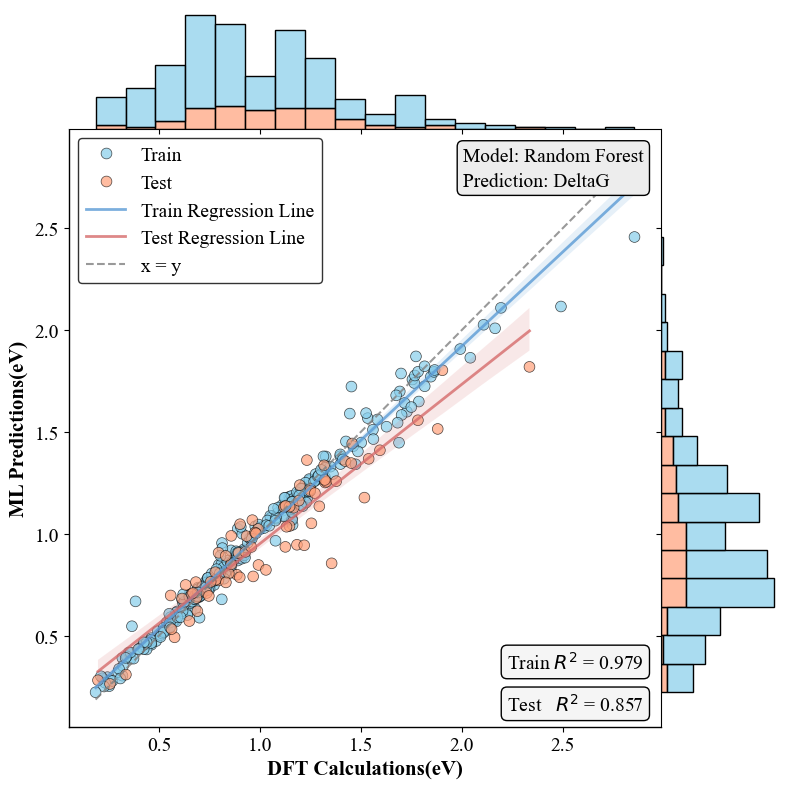

In [9]:
plot_true_vs_predicted(
    y_train,
    rf_y_train_pred,
    y_test,
    rf_y_test_pred,
    rf_r2_train,
    rf_r2_test,
    model_name="Random Forest",
    Prediction="DeltaG",
    output_file="./Photo-temp/RF-R20.85-dg.tiff")

In [10]:
from joblib import dump
import joblib
#
# # 保存模型到文件
dump(rf, './Modle/RF-R2-0.845-DG_1.joblib')
# print("模型已保存为 'optimized_random_forest_model.joblib'")

#rf = joblib.load("./Modle/RF-R2-0.903-FM.joblib")

['./Modle/RF-R2-0.845-DG_1.joblib']

In [11]:
from sklearn.model_selection import KFold, cross_val_score

# 设置K折
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# 执行交叉验证
scores_R2 = cross_val_score(rf, X_train_scaled, y_train, cv=kf, scoring='r2')
scores_MSE = cross_val_score(rf, X_train_scaled, y_train, cv=kf, scoring='neg_mean_squared_error')
scores_MAE = cross_val_score(rf, X_train_scaled, y_train, cv=kf, scoring='neg_mean_absolute_error')

print("每折R2:", scores_R2)
print("平均R2:", scores_R2.mean())
print("每折MSE:", scores_MSE)
print("平均MSE:", scores_MSE.mean())
print("每折MAE:", scores_MAE)
print("平均MAE:", scores_MAE.mean())

每折R2: [0.89637262 0.89209197 0.91992064 0.89390044 0.65183787 0.86436192
 0.82983529 0.85768745 0.93631036 0.85285882]
平均R2: 0.8595177390112504
每折MSE: [-0.01700034 -0.02441653 -0.0100649  -0.01766069 -0.11948015 -0.02288685
 -0.03296974 -0.03416268 -0.01245257 -0.02917121]
平均MSE: -0.032026565532966775
每折MAE: [-0.09132567 -0.08749404 -0.06560749 -0.10901742 -0.16771677 -0.0909709
 -0.12158414 -0.12955653 -0.07996586 -0.13533378]
平均MAE: -0.10785725941287361


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim

X_T = scaler.fit_transform(X_D)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_T, dtype=torch.float32)
y_train_tensor = torch.tensor(y_D, dtype=torch.float32).view(-1, 1)
# X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
# y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Display tensor shapes to verify
X_train_tensor.shape, y_train_tensor.shape

(torch.Size([364, 29]), torch.Size([364, 1]))

In [13]:
# 移动到设备
device = torch.device("cpu")  # 如需GPU支持更改为 'cuda' 或 'mps'

# Wasserstein GAN: Generator
class Generator(nn.Module):
    def __init__(self, input_dim, x_dim, y_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),  # 增加神经元数
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(512, momentum=0.8),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(256, momentum=0.8),
            nn.Linear(256, x_dim + y_dim)
        )

    def forward(self, z):
        output = self.model(z)
        x_gen = output[:, :-1]
        y_gen = output[:, -1:]
        # 强化数据向两侧扩展
        x_gen = torch.tanh(x_gen) * 5  # 控制范围在 -5 到 5
        y_gen = torch.tanh(y_gen) * 5
        return x_gen, y_gen


# Wasserstein GAN with Gradient Penalty: Critic
class CriticWithGP(nn.Module):
    def __init__(self, input_dim):
        super(CriticWithGP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x, y):
        combined = torch.cat((x, y), dim=1)
        return self.model(combined)

    def gradient_penalty(self, real_samples, fake_samples):
        # Random weight term for interpolation between real and fake samples
        alpha = torch.rand(real_samples.size(0), 1).to(device)
        interpolates = (alpha * real_samples + (1 - alpha) * fake_samples).requires_grad_(True)
        critic_output = self(interpolates[:, :-1], interpolates[:, -1:])
        gradients = torch.autograd.grad(
            outputs=critic_output,
            inputs=interpolates,
            grad_outputs=torch.ones(critic_output.size()).to(device),
            create_graph=True,
            retain_graph=True,
            only_inputs=True
        )[0]
        gradients = gradients.view(gradients.size(0), -1)
        gp = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
        return gp

In [14]:
# Initialize models and optimizers
latent_dim = 20  # Dimensionality of noise
x_dim = X_train_tensor.shape[1]  # X 的维度
y_dim = 1  # Target dimension

# Initialize models
generator = Generator(input_dim=latent_dim, x_dim=x_dim, y_dim=y_dim)
critic = CriticWithGP(input_dim=x_dim + y_dim)

optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_C = optim.Adam(critic.parameters(), lr=0.0002, betas=(0.5, 0.999))

lambda_gp = 10  # Gradient penalty coefficient

device = torch.device("cpu")  # Change to "cuda" if using GPU
generator.to(device)
critic.to(device)

CriticWithGP(
  (model): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [15]:
# Training parameters
epochs = 10000
batch_size = 64
critic_iterations = 5  # Train critic more frequently than generator
weight_clipping_limit = 0.01

d_losses = []
g_losses = []

# Training loop
for epoch in range(epochs):
    for _ in range(critic_iterations):
        idx = np.random.randint(0, X_train_tensor.size(0), batch_size)
        real_x = X_train_tensor[idx].to(device)
        real_y = y_train_tensor[idx].to(device)

        z = torch.randn(batch_size, latent_dim).to(device)
        fake_x, fake_y = generator(z)

        real_samples = torch.cat((real_x, real_y), dim=1)
        fake_samples = torch.cat((fake_x.detach(), fake_y.detach()), dim=1)

        # Critic loss with gradient penalty
        real_output = critic(real_x, real_y)
        fake_output = critic(fake_x.detach(), fake_y.detach())
        gp = critic.gradient_penalty(real_samples, fake_samples)
        d_loss = -torch.mean(real_output) + torch.mean(fake_output) + lambda_gp * gp

        optimizer_C.zero_grad()
        d_loss.backward()
        optimizer_C.step()

    z = torch.randn(batch_size, latent_dim).to(device)
    fake_x, fake_y = generator(z)

    # Generator loss with edge guidance
    fake_output = critic(fake_x, fake_y)
    edge_penalty = torch.mean((torch.abs(fake_x) - 3).clamp(min=0) ** 2)  # Edge constraint
    g_loss = -torch.mean(fake_output) + 0.1 * edge_penalty

    optimizer_G.zero_grad()
    g_loss.backward()
    optimizer_G.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}/{epochs} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch 0/10000 | D Loss: 8.4414 | G Loss: -0.0399
Epoch 100/10000 | D Loss: -0.3899 | G Loss: 1.4258
Epoch 200/10000 | D Loss: -1.5119 | G Loss: 3.6316
Epoch 300/10000 | D Loss: -0.5890 | G Loss: 2.4712
Epoch 400/10000 | D Loss: -0.3949 | G Loss: 2.0275
Epoch 500/10000 | D Loss: -0.2429 | G Loss: 1.8389
Epoch 600/10000 | D Loss: -0.4900 | G Loss: 1.8141
Epoch 700/10000 | D Loss: -0.2324 | G Loss: 1.9115
Epoch 800/10000 | D Loss: -0.3970 | G Loss: 2.0632
Epoch 900/10000 | D Loss: -0.3219 | G Loss: 2.3348
Epoch 1000/10000 | D Loss: -0.4599 | G Loss: 2.7736
Epoch 1100/10000 | D Loss: -0.4329 | G Loss: 3.4081
Epoch 1200/10000 | D Loss: -0.6386 | G Loss: 4.0467
Epoch 1300/10000 | D Loss: -0.5521 | G Loss: 4.9043
Epoch 1400/10000 | D Loss: -0.8094 | G Loss: 5.9502
Epoch 1500/10000 | D Loss: -0.7549 | G Loss: 6.7247
Epoch 1600/10000 | D Loss: -0.7835 | G Loss: 7.5787
Epoch 1700/10000 | D Loss: -0.8173 | G Loss: 8.3690
Epoch 1800/10000 | D Loss: -0.5914 | G Loss: 8.9267
Epoch 1900/10000 | D Los

In [16]:
# Visualize generated data
num_samples = 500
z = torch.randn(num_samples, latent_dim).to(device)
X_gen, y_gen = generator(z)

# Convert to numpy
X_gen = X_gen.detach().cpu().numpy()
y_gen = y_gen.detach().cpu().numpy()

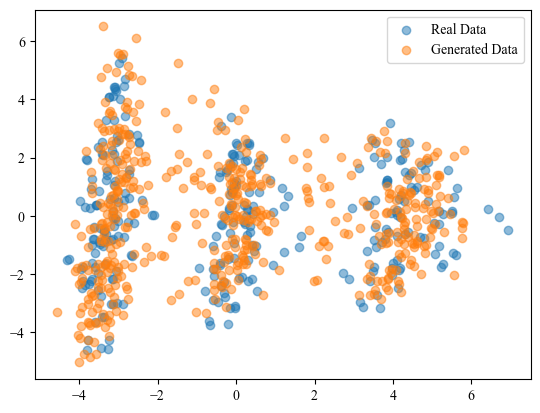

In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA for visualization
pca = PCA(n_components=2)
real_data_pca = pca.fit_transform(X_train_scaled)
gen_data_pca = pca.transform(X_gen)

plt.scatter(real_data_pca[:, 0], real_data_pca[:, 1], label="Real Data", alpha=0.5)
plt.scatter(gen_data_pca[:, 0], gen_data_pca[:, 1], label="Generated Data", alpha=0.5)
plt.legend()
plt.show()

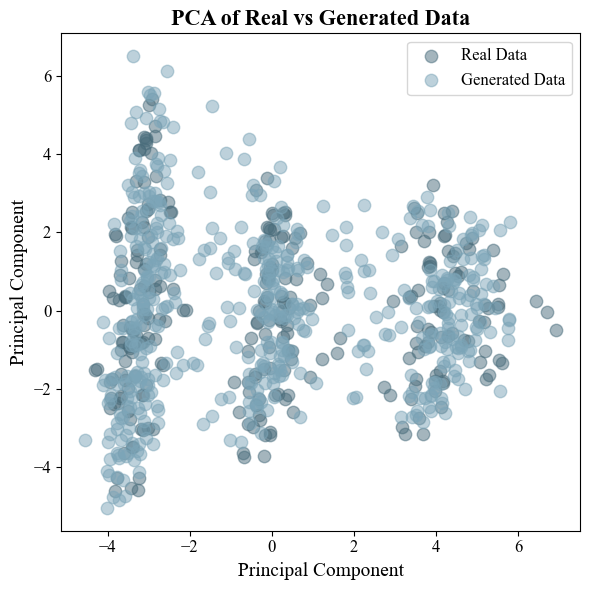

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA for visualization
pca = PCA(n_components=2)
real_data_pca = pca.fit_transform(X_train_scaled)
gen_data_pca = pca.transform(X_gen)

# Create the figure with specific size
plt.figure(figsize=(6, 6))

# Scatter plot with updated colors and no grid
plt.scatter(real_data_pca[:, 0], real_data_pca[:, 1], label="Real Data", alpha=0.5,c="#4A6D7C",  s=80)
plt.scatter(gen_data_pca[:, 0], gen_data_pca[:, 1], label="Generated Data", alpha=0.5,c="#7CA5B8",   s=80)

# Adding labels and title
plt.title('PCA of Real vs Generated Data', fontsize=16, fontweight='bold')
plt.xlabel('Principal Component', fontsize=14)
plt.ylabel('Principal Component', fontsize=14)

# Customize tick parameters
plt.tick_params(axis='both', which='major', labelsize=12)

# Show the legend on the right side of the plot
plt.legend(fontsize=12, loc='upper right', bbox_to_anchor=(1, 1))

# Display the plot
plt.tight_layout()  # To ensure everything fits well in the figure
plt.savefig("./Photo-temp/generatedata.tiff", format="tiff", dpi=600, bbox_inches="tight")
plt.show()

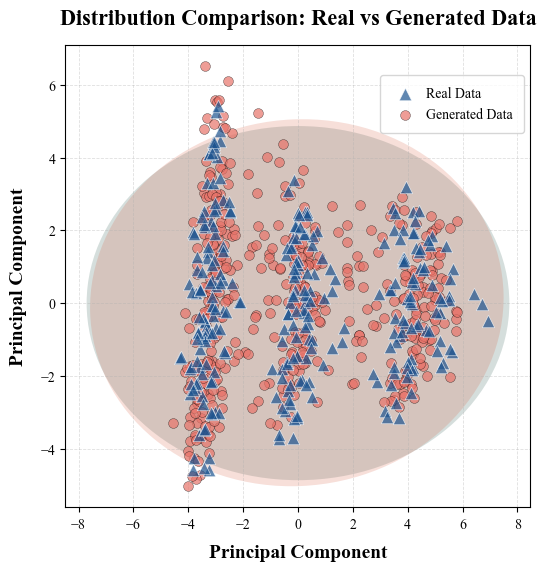

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# PCA for visualization
pca = PCA(n_components=2)
real_data_pca = pca.fit_transform(X_train_scaled)
gen_data_pca = pca.transform(X_gen)

# 设置全局样式（模仿Nature期刊风格）
plt.style.use("seaborn-v0_8-pastel")  # 柔和背景
plt.rcParams["font.family"] = "Times New Roman"  # 学术常用无衬线字体

fig, ax = plt.subplots(figsize=(6, 6))

# 散点图（添加edgecolor和不同marker）
ax.scatter(real_data_pca[:, 0], real_data_pca[:, 1],
           label="Real Data", alpha=0.7, s=80,
           c="#1D5490", edgecolor="white", linewidth=0.5,
           marker="^", zorder=3)  # zorder控制图层顺序

ax.scatter(gen_data_pca[:, 0], gen_data_pca[:, 1],
           label="Generated Data", alpha=0.7, s=50,
           c="#E8746A", edgecolor="black", linewidth=0.3,
           marker="o", zorder=2)

# 添加分布椭圆（可选，增强统计学表达）
from matplotlib.patches import Ellipse
def add_ellipse(data, ax, color):
    cov = np.cov(data.T)
    lambda_, v = np.linalg.eig(cov)
    angle = np.degrees(np.arctan2(v[1,0], v[0,0]))
    ell = Ellipse(xy=np.mean(data, axis=0),
                  width=2*np.sqrt(5.991*lambda_[0]),  # 95%置信区间
                  height=2*np.sqrt(5.991*lambda_[1]),
                  angle=angle,
                  fc=color, alpha=0.2, zorder=1)
    ax.add_patch(ell)

add_ellipse(real_data_pca, ax, "#2E5D54")
add_ellipse(gen_data_pca, ax, "#D95F43")

# 坐标轴标注
ax.set_xlabel("Principal Component", fontsize=14, labelpad=10,fontweight='bold')
ax.set_ylabel("Principal Component", fontsize=14, labelpad=10,fontweight='bold')
ax.set_title("Distribution Comparison: Real vs Generated Data",
             fontsize=16, pad=15, weight="semibold")

# 图例和网格
ax.legend(fontsize=10, frameon=True, shadow=False,
          borderpad=0.8, handletextpad=0.5,
          loc="upper right", bbox_to_anchor=(1, 0.95))
ax.grid(True, linestyle="--", alpha=0.4, linewidth=0.6)

# 保存设置（推荐矢量格式）
plt.savefig("./Photo-temp/generatedata.tiff",  # PDF更清晰
            format="tiff", dpi=600,
            bbox_inches="tight", transparent=True)
plt.show()

In [20]:
import joblib

rf = joblib.load("./Modle/RF-R2-0.845-DG_1.joblib")

In [21]:
y_gen_may = rf.predict(X_gen)

In [22]:
X_train_augmented_test = np.vstack((X_train_scaled, X_gen))
y_train_augmented_test = np.hstack((y_train, y_gen_may))

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_train_augmented_test, y_train_augmented_test, test_size=0.1, random_state=42)

In [24]:
from sklearn.ensemble import RandomForestRegressor

rf_1 = RandomForestRegressor()
rf_1.fit(X_train,y_train)

RandomForestRegressor()

In [25]:
# 获取 X_train 的列名称
column_names = data.drop(["delta G","Insert-Atom","Pt-Fold","Melting-point1","Density1",
                          "Ionization-energy1","Atomic-mass1","ID-1","Radius-1",
                          "Electronegativity-1","Formation-Energy","d-center"], axis=1).columns.tolist()

# 创建 DataFrame
augmented_data = pd.DataFrame(X_train_augmented_test, columns=column_names)
augmented_data["delta-g"] = y_train_augmented_test  # 添加目标列

# 导出为 CSV 文件
augmented_data.to_csv("./Data/augmented_training_data.csv", index=False)
print("数据已导出为 'augmented_training_data_1.csv'")

数据已导出为 'augmented_training_data_1.csv'


In [26]:
import joblib

joblib.dump(rf_1,"./Modle/RF-R2-0.92-DG_1.joblib")

['./Modle/RF-R2-0.92-DG_1.joblib']

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rf_y_train_pred = rf_1.predict(X_train)
rf_y_test_pred = rf_1.predict(X_test)

mse_train = mean_squared_error(y_train, rf_y_train_pred)
mse_test = mean_squared_error(y_test,rf_y_test_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, rf_y_train_pred)
rf_r2_train = r2_score(y_train, rf_y_train_pred)
rf_r2_test = r2_score(y_test,rf_y_test_pred)

# 打印评估指标
print("均方误差 (MSE)测试集:", mse_train)
print("均方误差 (MSE)训练集:", mse_test)
print("均方根误差 (RMSE):", rmse_train)
print("平均绝对误差 (MAE):", mae_train)
print("拟合优度 (R-squared)训练集:", rf_r2_train)
print("拟合优度 (R-squared)测试集:", rf_r2_test)

均方误差 (MSE)测试集: 0.001744131574766228
均方误差 (MSE)训练集: 0.0066250999918139345
均方根误差 (RMSE): 0.04176280132805064
平均绝对误差 (MAE): 0.023078290010098486
拟合优度 (R-squared)训练集: 0.9909094777481532
拟合优度 (R-squared)测试集: 0.9659077349970381


In [28]:
from sklearn.model_selection import KFold, cross_val_score

# 设置K折
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# 执行交叉验证
scores_R2 = cross_val_score(rf_1, X_train_augmented_test, y_train_augmented_test, cv=kf, scoring='r2')
scores_MSE = cross_val_score(rf_1, X_train_augmented_test, y_train_augmented_test, cv=kf, scoring='neg_mean_squared_error')
scores_MAE = cross_val_score(rf_1, X_train_augmented_test, y_train_augmented_test, cv=kf, scoring='neg_mean_absolute_error')

print("每折R2:", scores_R2)
print("平均R2:", scores_R2.mean())
print("每折MSE:", scores_MSE)
print("平均MSE:", scores_MSE.mean())
print("每折MAE:", scores_MAE)
print("平均MAE:", scores_MAE.mean())

每折R2: [0.96778636 0.94239939 0.93229824 0.97295219 0.92158594 0.96958808
 0.97346497 0.8547299  0.95798163 0.92424999]
平均R2: 0.9417036680499233
每折MSE: [-0.00634023 -0.01089417 -0.01477686 -0.00660422 -0.01551816 -0.00493493
 -0.00380669 -0.02917215 -0.0081037  -0.01227661]
平均MSE: -0.011242773639857942
每折MAE: [-0.04607589 -0.0630056  -0.06519483 -0.05328561 -0.06768688 -0.05055987
 -0.04399763 -0.07390869 -0.06213826 -0.0688549 ]
平均MAE: -0.05947081589959398


In [29]:
from sklearn.model_selection import cross_val_predict

y_cv = cross_val_predict(rf_1, X_train_augmented_test, y_train_augmented_test, cv = kf)

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def plot_true_vs_predicted(y_train, y_train_pred, y_test, y_test_pred, r2_train, r2_test, model_name="Random Forest",
                           Prediction="GeltaG", output_file=None):
    """
    绘制真实值与预测值的对比图，包含训练集和测试集的散点图和回归线。

    参数：
    - y_train: array-like, 训练集真实值
    - y_train_pred: array-like, 训练集预测值
    - y_test: array-like, 测试集真实值
    - y_test_pred: array-like, 测试集预测值
    - r2_train: float, 训练集 R^2 值
    - r2_test: float, 测试集 R^2 值
    - model_name: str, 模型名称（默认 "Random Forest"）
    - output_file: str, 可选，保存输出图像的文件路径（默认 None，表示不保存）

    返回：
    - 显示生成的图像。
    """
    # 设置字体为 Times New Roman
    plt.rc('font', family='Times New Roman')

    # 创建包含训练集和测试集真实值与预测值的数据框
    data_train = pd.DataFrame({
        'True': y_train,
        'Predicted': y_train_pred,
        'Data Set': 'Train'
    })

    data_test = pd.DataFrame({
        'True': y_test,
        'Predicted': y_test_pred,
        'Data Set': 'Test'
    })

    # 合并训练集和测试集的数据框
    data = pd.concat([data_train, data_test])

    # 自定义调色板
    palette = {'Train': '#87CEEB', 'Test': '#FFA07A'}

    # 创建 JointGrid 对象
    plt.figure(figsize=(8, 8), dpi=1200)
    g = sns.JointGrid(data=data, x="True", y="Predicted", hue="Data Set", height=8, palette=palette,)

    # 绘制中心的散点图
    g.plot_joint(sns.scatterplot, alpha=0.7, s=60, edgecolor="k", linewidth=0.5)

    # 添加训练集的回归线
    sns.regplot(data=data_train, x="True", y="Predicted", scatter=False, ax=g.ax_joint,
                color='#5B9BD5', label='Train Regression Line', line_kws={'lw': 2, 'alpha': 0.8})

    # 添加测试集的回归线
    sns.regplot(data=data_test, x="True", y="Predicted", scatter=False, ax=g.ax_joint,
                color='#D66B6B', label='Test Regression Line', line_kws={'lw': 2, 'alpha': 0.8})

    # 添加边缘的柱状图，调整柱状图间距
    g.plot_marginals(
        sns.histplot, kde=False, element='bars', multiple='stack', alpha=0.7)

    # 添加拟合优度文本在右下角
    ax = g.ax_joint
    ax.text(0.97, 0.09, f'Train $R^2$ = {r2_train:.3f}', transform=ax.transAxes, fontsize=14,
            verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="#F5F5F5"))
    ax.text(0.97, 0.02, f'Test   $R^2$ = {r2_test:.3f}', transform=ax.transAxes, fontsize=14,
            verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="#F5F5F5"))

    # 在右上角添加模型名称文本
    ax.text(0.97, 0.97, f'Model: {model_name}\nPrediction: {Prediction}', transform=ax.transAxes, linespacing=1.5,
            fontsize=14, verticalalignment='top', horizontalalignment='right', multialignment='left',
            bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="#EDEDED"))

    # 添加中心线
    ax.plot([data['True'].min(), data['True'].max()], [data['True'].min(), data['True'].max()],
            c="gray", alpha=0.8, linestyle='--', label='x = y')

    # 添加图例
    ax.legend(loc='upper left', fontsize=14, frameon=True, facecolor="white", edgecolor="black", fancybox=True)

    # 手动描边框线，确保边框闭合
    for spine in ['top', 'right', 'left', 'bottom']:
        g.ax_joint.spines[spine].set_linewidth(1)  # 设置边框线宽度为2
        g.ax_joint.spines[spine].set_edgecolor("black")  # 设置边框颜色为黑色

    # 调整横纵坐标标签字体大小
    g.ax_joint.set_xlabel("DFT Calculations(eV)", fontsize=15, fontweight='bold')  # 横坐标标签字体大小
    g.ax_joint.set_ylabel("ML Predictions(eV)", fontsize=15, fontweight='bold')  # 纵坐标标签字体大小

    # 调整横纵坐标刻度字体大小
    g.ax_joint.tick_params(axis='both', labelsize=14)  # 刻度字体大小

    # 确保边缘布局完整
    plt.tight_layout()
    plt.subplots_adjust(hspace=0, wspace=0)  # 调整子图间距，使边缘更紧凑

    # 如果提供了文件路径，则保存图像
    if output_file:
        plt.savefig(output_file, format='tiff', dpi=1200, bbox_inches='tight')

    # 显示图像
    plt.show()

<Figure size 9600x9600 with 0 Axes>

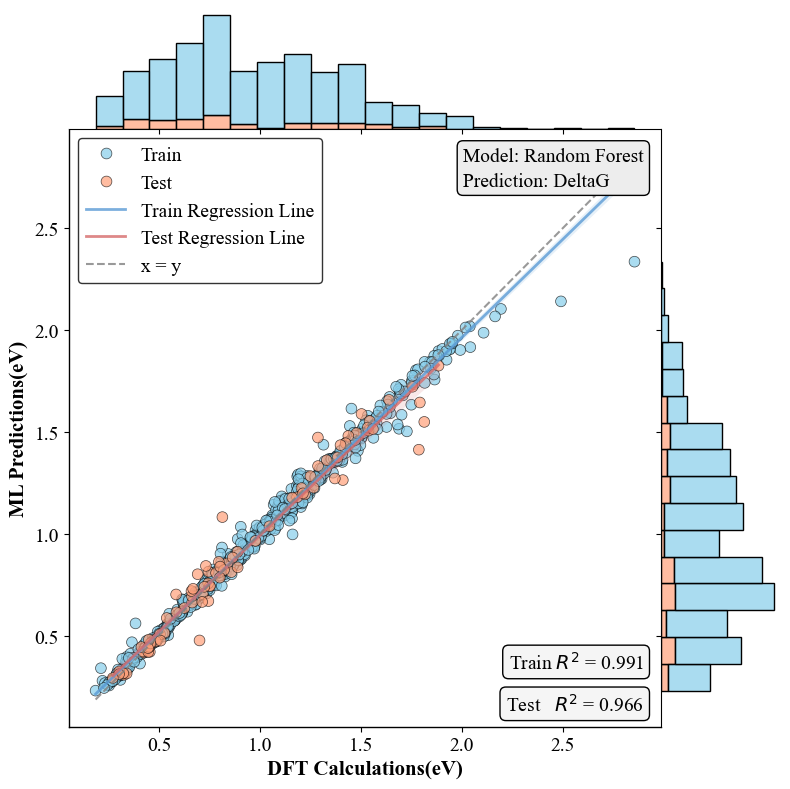

In [31]:
plot_true_vs_predicted(
    y_train,
    rf_y_train_pred,
    y_test,
    rf_y_test_pred,
    rf_r2_train,
    rf_r2_test,
    model_name="Random Forest",
    Prediction="DeltaG",
    output_file="./Photo-temp/RF-R20.92-dg.tiff")

In [32]:
import shap

Data_Shap = data.drop(["delta G","Insert-Atom","Pt-Fold","Melting-point1","Density1","Ionization-energy1","Atomic-mass1","ID-1","Radius-1","Electronegativity-1","Formation-Energy","d-center"],axis=1)
# 假设 data 是你的原始数据框
feature_names = Data_Shap.columns.tolist()  # 自动获取列名作为特征名称

# 确保训练和测试数据带有列名
X_train_scaled = pd.DataFrame(X_train, columns=feature_names)
X_test_scaled = pd.DataFrame(X_test, columns=feature_names)

explainer = shap.Explainer(rf_1, X_train)  # 使用训练数据创建解释器
shap_values = explainer(X_train)         # 计算测试集的 SHAP 值

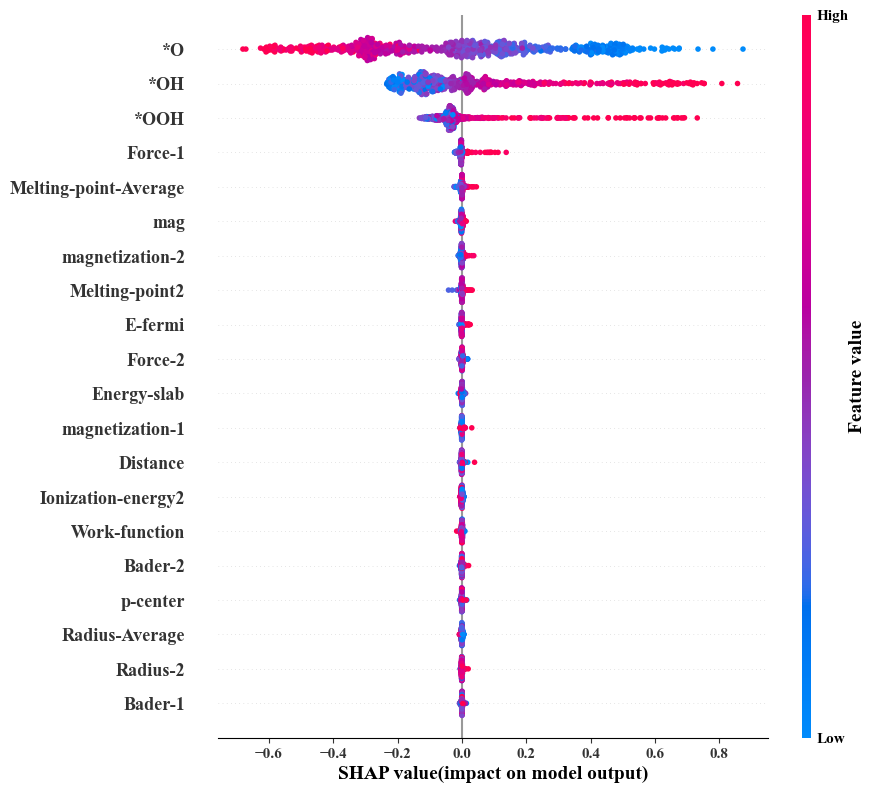

In [33]:
import shap
import matplotlib.pyplot as plt

# 假设 shap_values、X_train_scaled 和 feature_names 已经定义
# 生成 SHAP Summary Plot
plt.rcParams.update({
    'font.family': 'serif',          # 设置衬线字体族
    'font.serif': 'Times New Roman', # 指定Times New Roman
    'font.size': 14,                 # 基础字号
    'axes.labelsize': 14,            # 坐标轴标签字号
    'xtick.labelsize': 14,           # X轴刻度字号
    'ytick.labelsize': 14,           # Y轴特征名称字号
    'axes.grid': False ,              # 完全关闭网格线
    'font.weight': 'bold',
})
shap.summary_plot(shap_values, X_train, feature_names=feature_names, show=False)

# 手动设置底部 "SHAP Values" 标签的字体
ax = plt.gca()
ax.set_xlabel("SHAP value(impact on model output)", fontsize=14, fontweight='bold')  # 显式覆盖标签属性

cb = plt.gcf().axes[-1]  # 获取颜色条对象
cb.set_ylabel("Feature value", fontsize=14, fontweight='bold')

# 设置图像保存参数并保存为 TIFF 格式
plt.gca().grid(False)  # 确保网格线已关闭
plt.gcf().set_size_inches(10, 8)  # 可根据需求调整图像尺寸
plt.savefig("./Photo-temp/shap_summary_plot.tiff", format="tiff", dpi=1200, bbox_inches="tight")
plt.show()

图像已保存到: ./Photo-temp/shap_bar_with_colormap.tiff


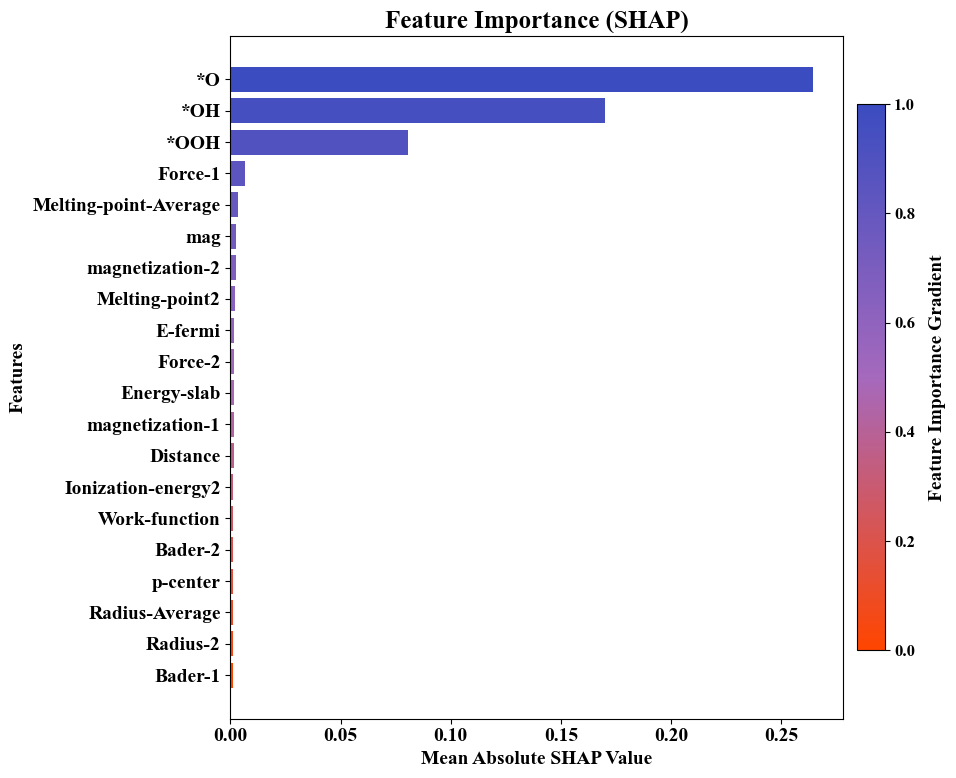

In [34]:
import shap
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 创建输出目录
import os
output_dir = "./Photo-temp/"
os.makedirs(output_dir, exist_ok=True)  # 如果目录不存在则创建

# 假设 shap_values 是 shap.Explanation 类型
# 提取 SHAP 值数组
shap_values_array = shap_values.values  # 提取 SHAP 值
mean_shap_values = np.abs(shap_values_array).mean(axis=0)  # 按特征计算平均绝对 SHAP 值
sorted_indices = np.argsort(mean_shap_values)[::-1]  # 按降序排序

# 提取前 20 个重要特征及其对应的 SHAP 值
top_20_indices = sorted_indices[:20]
top_20_shap_values = mean_shap_values[top_20_indices]
top_20_feature_names = [feature_names[i] for i in top_20_indices]

# 创建自定义的 colormap (蓝到粉到红)
custom_cmap = LinearSegmentedColormap.from_list(
    "custom_gradient", ["#3B4CC0", "#A569BD", "#FF4500"]  # 蓝、粉、红渐变
)
custom_cmap_2 = LinearSegmentedColormap.from_list(
    "custom_gradient", ["#FF4500", "#A569BD", "#3B4CC0"]  # 蓝、粉、红渐变
)
colors = custom_cmap(np.linspace(0, 1, len(top_20_shap_values)))

# 设置全局字体
import matplotlib
matplotlib.rc("font", family="Times New Roman")  # 设置字体为 Times New Roman

# 调整图形大小
fig, ax = plt.subplots(figsize=(10, 8))  # 图形宽度为 12，高度为 10

# 绘制 SHAP 特征重要性条形图
bars = ax.barh(
    np.arange(len(top_20_shap_values))[::-1],  # 翻转索引，让最大值在顶部
    top_20_shap_values,                       # 特征的平均绝对 SHAP 值
    color=colors                              # 渐变色
)

# 添加标题和坐标轴标签
ax.set_title("Feature Importance (SHAP)", fontsize=18, fontweight="bold")  # 标题
ax.set_xlabel("Mean Absolute SHAP Value", fontsize=14, fontweight="bold")  # 横轴标签
ax.set_ylabel("Features", fontsize=14, fontweight="bold")  # 纵轴标签
ax.set_yticks(np.arange(len(top_20_shap_values))[::-1])  # 翻转标签
ax.set_yticklabels(top_20_feature_names, fontsize=14, fontweight="bold")

# 添加颜色条（映射到渐变色）
sm = plt.cm.ScalarMappable(cmap=custom_cmap_2, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", shrink=0.8, pad=0.02)
cbar.set_label("Feature Importance Gradient", fontsize=14, labelpad=10, fontweight="bold")
cbar.ax.tick_params(labelsize=12)

# 确保图形布局紧凑
plt.tight_layout()

# 保存图像到指定目录
output_path = os.path.join(output_dir, "shap_bar_with_colormap.tiff")
plt.savefig(output_path, format="tiff", dpi=1200, bbox_inches="tight")

# 显示保存路径并检查
print(f"图像已保存到: {output_path}")

# 显示图形
plt.show()

# 重置为默认配置（取消全局加粗）
plt.rcdefaults()

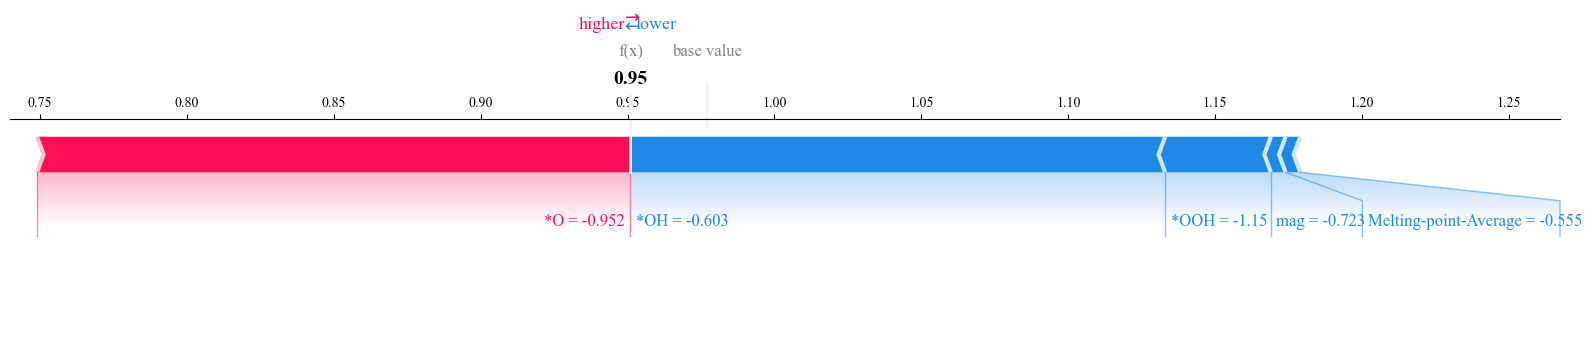

<Figure size 640x480 with 0 Axes>

In [35]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# 手动设置基准值 (base_value)，假设为模型预测的平均值
base_value = np.mean(rf.predict(X_train))  # 替换为实际模型的预测方法

# 提取 SHAP 值数组
shap_values_array = shap_values.values  # 提取 SHAP 值数组

# 指定样本索引
sample_index = 0
sample_shap_values = shap_values_array[sample_index]  # 当前样本的 SHAP 值
sample_features = X_train_scaled.iloc[sample_index]  # 当前样本的特征值

# 只显示最重要的几个特征（例如前 5 个）
top_n = 5
sorted_indices = np.argsort(np.abs(sample_shap_values))[::-1][:top_n]  # 按绝对值降序排序
top_shap_values = sample_shap_values[sorted_indices]
top_features = sample_features.iloc[sorted_indices]
top_feature_names = [feature_names[i] for i in sorted_indices]

# 设置全局字体
import matplotlib
matplotlib.rc("font", family="Times New Roman")  # 设置字体为 Times New Roman

# 绘制力图
force_plot = shap.force_plot(
    base_value=round(base_value, 3),              # 保留三位小数的基准值
    shap_values=np.round(top_shap_values, 3),    # 保留三位小数的 SHAP 值
    features=np.round(top_features.values, 3),   # 保留三位小数的特征值
    feature_names=top_feature_names,             # 最重要的特征名称
    matplotlib=True                              # 使用 matplotlib 绘图
)

# 保存为高分辨率图像
plt.savefig("./Photo-temp/force_plot_top_features.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

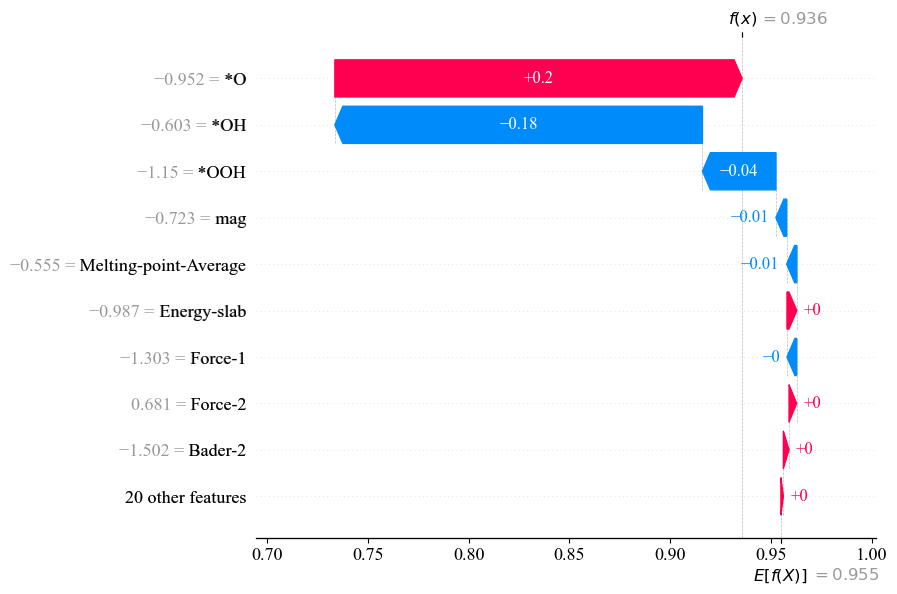

<Figure size 640x480 with 0 Axes>

In [36]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# 假设 shap_values 是一个 NumPy 数组，需要手动构造 Explanation 对象
sample_index = 0  # 指定样本索引

# 手动构造 shap.Explanation 对象
shap_values_explanation = shap.Explanation(
    values=shap_values[sample_index],  # 当前样本的 SHAP 值
    base_values=np.mean(rf.predict(X_train)),  # 模型的基准值
    data=X_train_scaled.iloc[sample_index],  # 当前样本的特征值
    feature_names=feature_names  # 特征名称
)

# 绘制瀑布图
shap.plots.waterfall(
    shap_values_explanation,  # 必须是 Explanation 对象
    max_display=10            # 显示前 10 个最重要特征
)

# 保存为高分辨率 TIFF 图像
plt.savefig("./Photo-temp/waterfall_plot.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
from sklearn.svm import SVR

svr = SVR()
svr.fit(X_train,y_train)

SVR()

In [38]:
svr_y_train_pred = svr.predict(X_train)
svr_y_test_pred = svr.predict(X_test)

mse_train = mean_squared_error(y_train, svr_y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, svr_y_train_pred)
svr_r2_train = r2_score(y_train, svr_y_train_pred)
svr_r2_test = r2_score(y_test,svr_y_test_pred)

# 打印评估指标
print("均方误差 (MSE):", mse_train)
print("均方根误差 (RMSE):", rmse_train)
print("平均绝对误差 (MAE):", mae_train)
print("拟合优度 (R-squared)训练集:", svr_r2_train)
print("拟合优度 (R-squared)测试集:", svr_r2_test)

均方误差 (MSE): 0.009164583647294049
均方根误差 (RMSE): 0.09573183194368552
平均绝对误差 (MAE): 0.0812793850178559
拟合优度 (R-squared)训练集: 0.9522336199975026
拟合优度 (R-squared)测试集: 0.8870220189140295


<Figure size 9600x9600 with 0 Axes>

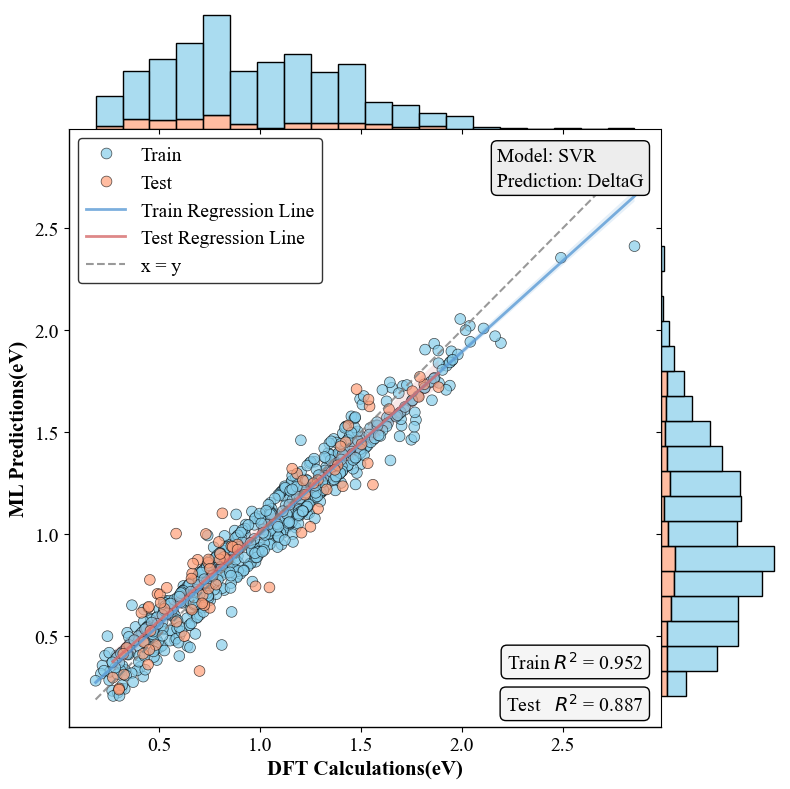

In [39]:
plot_true_vs_predicted(
    y_train,
    svr_y_train_pred,
    y_test,
    svr_y_test_pred,
    svr_r2_train,
    svr_r2_test,
    model_name="SVR",
    Prediction="DeltaG",
    output_file="./Photo-temp/SVR-R20.74-dg.tiff")

In [40]:
from sklearn.neural_network import MLPRegressor

MLP = MLPRegressor(hidden_layer_sizes=(128,128,64))
MLP.fit(X_train,y_train)

MLPRegressor(hidden_layer_sizes=(128, 128, 64))

In [41]:
neu_y_train_pred = MLP.predict(X_train)
neu_y_test_pred = MLP.predict(X_test)

mse_train = mean_squared_error(y_train, neu_y_train_pred)
mse_test = mean_squared_error(y_test, neu_y_test_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, neu_y_train_pred)
neu_r2_train = r2_score(y_train, neu_y_train_pred)
neu_r2_test = r2_score(y_test,neu_y_test_pred)

# 打印评估指标
print("均方误差 (MSE)训练集:", mse_train)
print("均方误差 (MSE)测试集:", mse_test)
print("均方根误差 (RMSE):", rmse_train)
print("平均绝对误差 (MAE):", mae_train)
print("拟合优度 (R-squared)训练集:", neu_r2_train)
print("拟合优度 (R-squared)测试集:", neu_r2_test)

均方误差 (MSE)训练集: 0.0018997095925206834
均方误差 (MSE)测试集: 0.017529179882108736
均方根误差 (RMSE): 0.043585658105857294
平均绝对误差 (MAE): 0.03356789780145724
拟合优度 (R-squared)训练集: 0.9900985954427373
拟合优度 (R-squared)测试集: 0.9097961620860283


<Figure size 9600x9600 with 0 Axes>

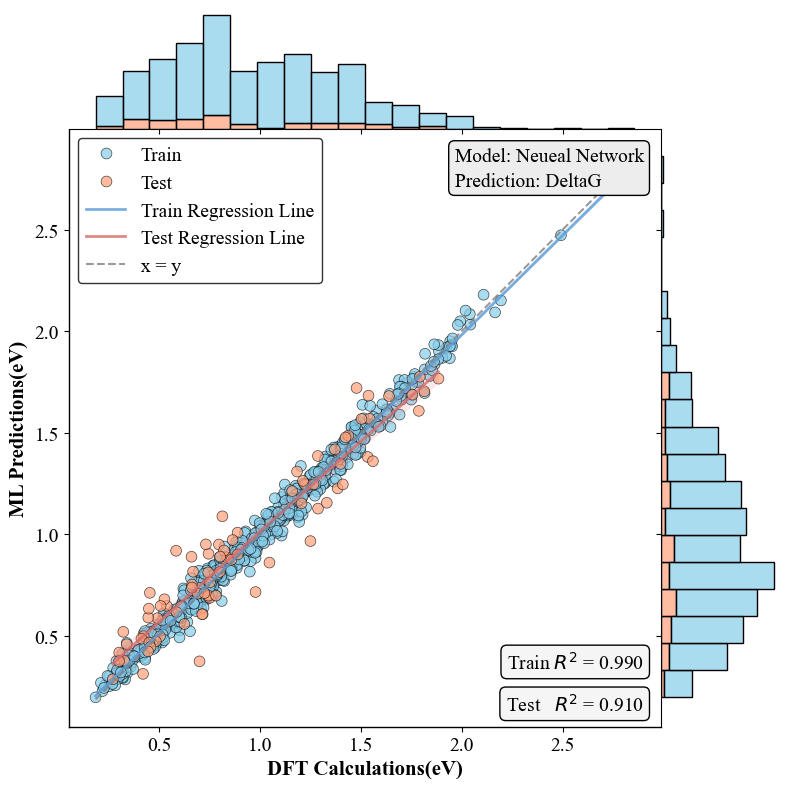

In [42]:
plot_true_vs_predicted(
    y_train,
    neu_y_train_pred,
    y_test,
    neu_y_test_pred,
    neu_r2_train,
    neu_r2_test,
    model_name="Neueal Network",
    Prediction="DeltaG",
    output_file="./Photo-temp/NN-R20.80-dg.tiff")

In [43]:
from sklearn.ensemble import AdaBoostRegressor

ada = AdaBoostRegressor()
ada.fit(X_train,y_train)

AdaBoostRegressor()

In [44]:
ada_y_train_pred = ada.predict(X_train)
ada_y_test_pred = ada.predict(X_test)

mse_train = mean_squared_error(y_train, ada_y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, ada_y_train_pred)
ada_r2_train = r2_score(y_train, ada_y_train_pred)
ada_r2_test = r2_score(y_test,ada_y_test_pred)

# 打印评估指标
print("均方误差 (MSE):", mse_train)
print("均方根误差 (RMSE):", rmse_train)
print("平均绝对误差 (MAE):", mae_train)
print("拟合优度 (R-squared)训练集:", ada_r2_train)
print("拟合优度 (R-squared)测试集:", ada_r2_test)

均方误差 (MSE): 0.02555383754153298
均方根误差 (RMSE): 0.15985567722646882
平均绝对误差 (MAE): 0.13522356431563862
拟合优度 (R-squared)训练集: 0.8668118092968304
拟合优度 (R-squared)测试集: 0.8609564236272995


<Figure size 9600x9600 with 0 Axes>

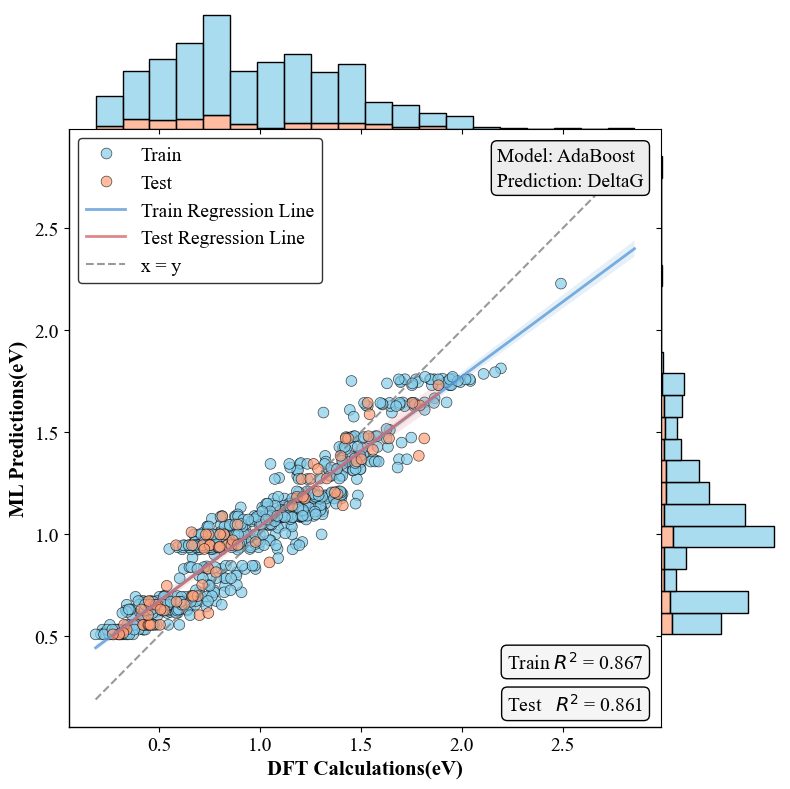

In [45]:
plot_true_vs_predicted(
    y_train,
    ada_y_train_pred,
    y_test,
    ada_y_test_pred,
    ada_r2_train,
    ada_r2_test,
    model_name="AdaBoost",
    Prediction="DeltaG",
    output_file="./Photo-temp/Ada-R20.92-dg.tiff")

In [46]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42,max_depth=12)
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=12, random_state=42)

In [47]:
dt_y_train_pred = dt_model.predict(X_train)
dt_y_test_pred = dt_model.predict(X_test)

mse_train = mean_squared_error(y_train, dt_y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, dt_y_train_pred)
dt_r2_train = r2_score(y_train, dt_y_train_pred)
dt_r2_test = r2_score(y_test,dt_y_test_pred)

# 打印评估指标
print("均方误差 (MSE):", mse_train)
print("均方根误差 (RMSE):", rmse_train)
print("平均绝对误差 (MAE):", mae_train)
print("拟合优度 (R-squared)训练集:", dt_r2_train)
print("拟合优度 (R-squared)测试集:", dt_r2_test)

均方误差 (MSE): 0.00017110879190582735
均方根误差 (RMSE): 0.013080855931697563
平均绝对误差 (MAE): 0.0054340116017677
拟合优度 (R-squared)训练集: 0.9991081703337003
拟合优度 (R-squared)测试集: 0.9074578222452371


<Figure size 9600x9600 with 0 Axes>

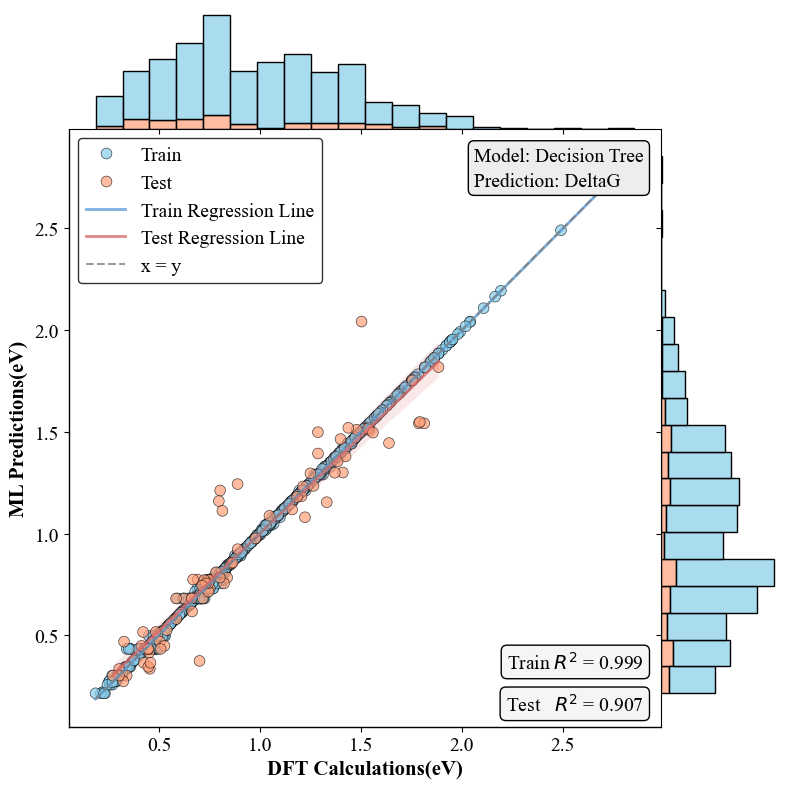

In [48]:
plot_true_vs_predicted(
    y_train,
    dt_y_train_pred,
    y_test,
    dt_y_test_pred,
    dt_r2_train,
    dt_r2_test,
    model_name="Decision Tree",
    Prediction="DeltaG",
    output_file="./Photo-temp/DT-R20.91-dg.tiff")

In [49]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.005, random_state=42)
lasso.fit(X_train, y_train)

Lasso(alpha=0.005, random_state=42)

In [50]:
lasso_y_train_pred = lasso.predict(X_train)
lasso_y_test_pred = lasso.predict(X_test)

mse_train = mean_squared_error(y_train, lasso_y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, lasso_y_train_pred)
lasso_r2_train = r2_score(y_train, lasso_y_train_pred)
lasso_r2_test = r2_score(y_test,lasso_y_test_pred)

# 打印评估指标
print("均方误差 (MSE):", mse_train)
print("均方根误差 (RMSE):", rmse_train)
print("平均绝对误差 (MAE):", mae_train)
print("拟合优度 (R-squared)训练集:", lasso_r2_train)
print("拟合优度 (R-squared)测试集:", lasso_r2_test)

均方误差 (MSE): 0.05640049616876227
均方根误差 (RMSE): 0.23748788636215168
平均绝对误差 (MAE): 0.17598920945695748
拟合优度 (R-squared)训练集: 0.7060371058840247
拟合优度 (R-squared)测试集: 0.6950736161478268


<Figure size 9600x9600 with 0 Axes>

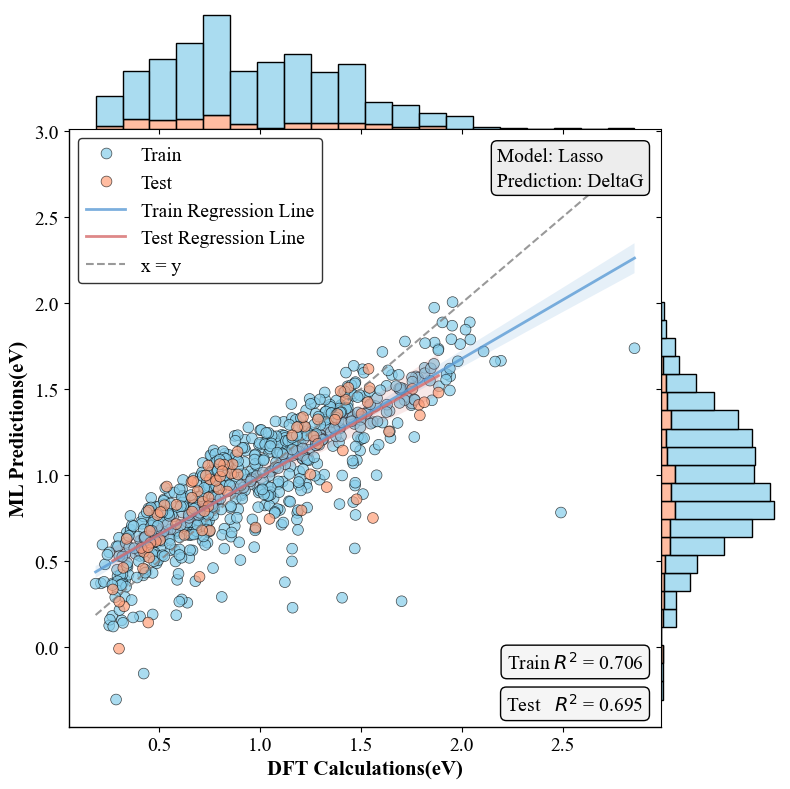

In [51]:
plot_true_vs_predicted(
    y_train,
    lasso_y_train_pred,
    y_test,
    lasso_y_test_pred,
    lasso_r2_train,
    lasso_r2_test,
    model_name="Lasso",
    Prediction="DeltaG",
    output_file="./Photo-temp/Lassio-R20.84-dg.tiff")

In [52]:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42)  # 默认参数
elastic_net.fit(X_train, y_train)

ElasticNet(alpha=0.01, random_state=42)

In [53]:
ela_y_train_pred = elastic_net.predict(X_train)
ela_y_test_pred = elastic_net.predict(X_test)

mse_train = mean_squared_error(y_train, ela_y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, ela_y_train_pred)
ela_r2_train = r2_score(y_train, ela_y_train_pred)
ela_r2_test = r2_score(y_test,ela_y_test_pred)

# 打印评估指标
print("均方误差 (MSE):", mse_train)
print("均方根误差 (RMSE):", rmse_train)
print("平均绝对误差 (MAE):", mae_train)
print("拟合优度 (R-squared)训练集:", ela_r2_train)
print("拟合优度 (R-squared)测试集:", ela_r2_test)

均方误差 (MSE): 0.05649329745014513
均方根误差 (RMSE): 0.23768318714234948
平均绝对误差 (MAE): 0.17649978059976978
拟合优度 (R-squared)训练集: 0.7055534198332611
拟合优度 (R-squared)测试集: 0.6948664862349742


<Figure size 9600x9600 with 0 Axes>

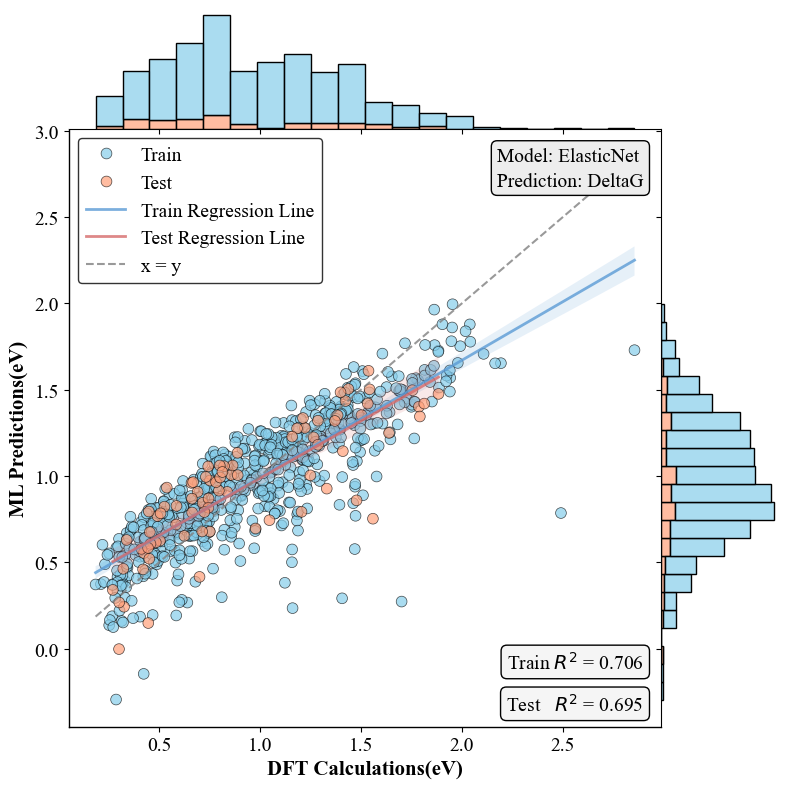

In [54]:
plot_true_vs_predicted(
    y_train,
    ela_y_train_pred,
    y_test,
    ela_y_test_pred,
    ela_r2_train,
    ela_r2_test,
    model_name="ElasticNet",
    Prediction="DeltaG",
    output_file="./Photo-temp/Ela-R20.84-dg.tiff")

In [55]:
import xgboost

xg = xgboost.XGBRegressor()
xg.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [56]:
xg_y_train_pred = xg.predict(X_train)
xg_y_test_pred = xg.predict(X_test)

mse_train = mean_squared_error(y_train, xg_y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, xg_y_train_pred)
xg_r2_train = r2_score(y_train, xg_y_train_pred)
xg_r2_test = r2_score(y_test,xg_y_test_pred)

# 打印评估指标
print("均方误差 (MSE):", mse_train)
print("均方根误差 (RMSE):", rmse_train)
print("平均绝对误差 (MAE):", mae_train)
print("拟合优度 (R-squared)训练集:", xg_r2_train)
print("拟合优度 (R-squared)测试集:", xg_r2_test)

均方误差 (MSE): 6.888440523743378e-07
均方根误差 (RMSE): 0.0008299662959267309
平均绝对误差 (MAE): 0.0005824998895948884
拟合优度 (R-squared)训练集: 0.9999964097019532
拟合优度 (R-squared)测试集: 0.9650578383120549


<Figure size 9600x9600 with 0 Axes>

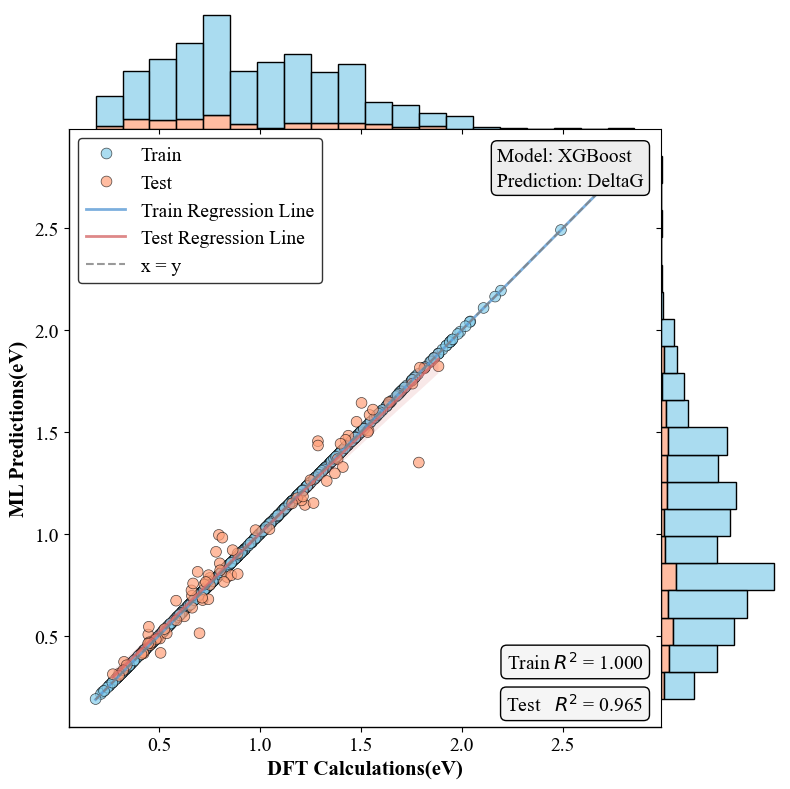

In [57]:
plot_true_vs_predicted(
    y_train,
    xg_y_train_pred,
    y_test,
    xg_y_test_pred,
    xg_r2_train,
    xg_r2_test,
    model_name="XGBoost",
    Prediction="DeltaG",
    output_file="./Photo-temp/Xg-R20.84-dg.tiff")